In [ ]:
# ============================================================
# Cell 0: Install dependencies & imports
# ============================================================
!pip install -q torchmetrics

import os, zipfile, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# ── Checkpoint 1: Student ID Seed ──────────────────────────


In [ ]:
# ============================================================
# Cell 1: Unzip data.zip and merge with CSV → master table
# ============================================================
ZIP_PATH  = "data.zip"          # path to the uploaded zip
CSV_PATH  = "chinese_mnist.csv"
EXTRACT_DIR = "data"

# Programmatically unzip (required by assignment)
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)
    print(f"Extracted {len(zf.namelist())} files to '{EXTRACT_DIR}/'")

# Load the CSV metadata
df = pd.read_csv(CSV_PATH)
print("\nCSV columns:", df.columns.tolist())
print(df.head(5))

# Build absolute image path for every row
# Filename pattern: input_{suite_id}_{sample_id}_{code}.jpg
# Images live inside  data/data/
def build_path(row):
    fname = f"input_{row['suite_id']}_{row['sample_id']}_{row['code']}.jpg"
    return os.path.join(EXTRACT_DIR, "data", fname)

df["filepath"] = df.apply(build_path, axis=1)

# Verify all files exist
missing = df[~df["filepath"].apply(os.path.exists)]
print(f"\nMissing files: {len(missing)}")

# code column (1-15) becomes our integer label (0-14)
df["label"] = df["code"] - 1

print(f"\nMaster table shape: {df.shape}")
print(df[["filepath", "value", "character", "label"]].head())

Extracted 15001 files to 'data/'

CSV columns: ['suite_id', 'sample_id', 'code', 'value', 'character']
   suite_id  sample_id  code  value character
0         1          1    10      9         九
1         1         10    10      9         九
2         1          2    10      9         九
3         1          3    10      9         九
4         1          4    10      9         九

Missing files: 0

Master table shape: (15000, 7)
                      filepath  value character  label
0   data/data/input_1_1_10.jpg      9         九      9
1  data/data/input_1_10_10.jpg      9         九      9
2   data/data/input_1_2_10.jpg      9         九      9
3   data/data/input_1_3_10.jpg      9         九      9
4   data/data/input_1_4_10.jpg      9         九      9


In [ ]:
# ============================================================
# Cell 2: Custom Dataset + DataLoader
# ============================================================

# Chinese character lookup (code 1-15 → character)
CODE_TO_CHAR = {
    1: "零", 2: "一", 3: "二", 4: "三", 5: "四",
    6: "五", 7: "六", 8: "七", 9: "八", 10: "九",
    11: "十", 12: "百", 13: "千", 14: "万", 15: "亿"
}
CODE_TO_VALUE = {
    1:0, 2:1, 3:2, 4:3, 5:4, 6:5, 7:6,
    8:7, 9:8, 10:9, 11:10, 12:100,
    13:1000, 14:10000, 15:100000000
}

class ChineseMNISTDataset(Dataset):
    """
    Custom Dataset for Chinese MNIST.
    Parses chinese_mnist.csv to map filepaths → integer labels (0-14).
    """
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = int(row["label"])          # 0-14
        if self.transform:
            image = self.transform(image)
        return image, label

# ── Transforms ────────────────────────────────────────────
TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std =[0.5, 0.5, 0.5]),
])

VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std =[0.5, 0.5, 0.5]),
])

# ── Train / Val split (80/20) ─────────────────────────────
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"],
    random_state=STUDENT_ID_LAST_4
)

BATCH_SIZE = 64   # ≤ 128 as required

train_dataset = ChineseMNISTDataset(train_df, transform=TRAIN_TRANSFORM)
val_dataset   = ChineseMNISTDataset(val_df,   transform=VAL_TRANSFORM)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}  |  Val samples: {len(val_dataset)}")
print(f"Train batches: {len(train_loader)}   |  Val batches: {len(val_loader)}")

Train samples: 12000  |  Val samples: 3000
Train batches: 188   |  Val batches: 47


/tmp/ipykernel_1647/3824034830.py:32: UserWarning: Glyph 19975 (\N{CJK UNIFIED IDEOGRAPH-4E07}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/3824034830.py:32: UserWarning: Glyph 20159 (\N{CJK UNIFIED IDEOGRAPH-4EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/3824034830.py:32: UserWarning: Glyph 21315 (\N{CJK UNIFIED IDEOGRAPH-5343}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/3824034830.py:32: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/3824034830.py:32: UserWarning: Glyph 19971 (\N{CJK UNIFIED IDEOGRAPH-4E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/3824034830.py:32: UserWarning: Glyph 20843 (\N{CJK UNIFIED IDEOGRAPH-516B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/3824034830.py:32: UserWarning: Glyph 20061 (\N{CJK UNIFIED IDEOGRAPH-4E5D}

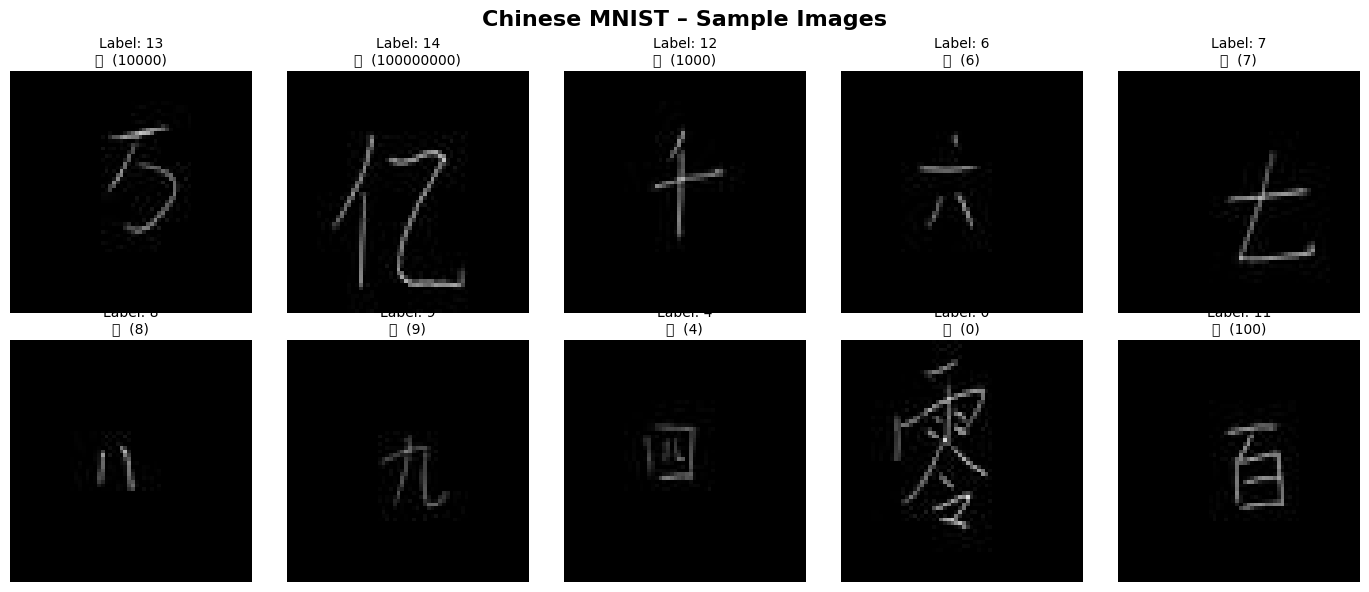

Saved: sample_grid.png


In [ ]:
# ============================================================
# Cell 3: Visualise 10 labelled sample images (2 × 5 grid)
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Chinese MNIST – Sample Images", fontsize=16, fontweight="bold")

# Pick one sample per class (first 10 classes for the grid)
shown = 0
used_labels = set()

# Use the RAW (un-normalised) val dataset for display
display_dataset = ChineseMNISTDataset(val_df, transform=transforms.Compose([
    transforms.Resize((64, 64)), transforms.ToTensor()
]))

for i in range(len(display_dataset)):
    img_tensor, lbl = display_dataset[i]
    if lbl not in used_labels:
        used_labels.add(lbl)
        ax = axes[shown // 5][shown % 5]
        ax.imshow(img_tensor.permute(1, 2, 0).numpy())
        code = lbl + 1                          # code is label+1
        char = CODE_TO_CHAR[code]
        val  = CODE_TO_VALUE[code]
        ax.set_title(f"Label: {lbl}\n{char}  ({val})",
                     fontsize=10, fontproperties="SimHei")  # SimHei for Chinese
        ax.axis("off")
        shown += 1
    if shown == 10:
        break

plt.tight_layout()
plt.savefig("sample_grid.png", dpi=150)
plt.show()
print("Saved: sample_grid.png")

In [ ]:
# ============================================================
# Cell 4: CNN Architecture – Shape-Trace comments required
# ============================================================

class ChineseMNISTCNN(nn.Module):
    """
    CNN for 15-class Chinese MNIST (64x64 RGB input).
    Architecture: 4 Conv blocks → 2 FC layers.
    """
    def __init__(self, dropout_p=0.4, num_classes=15):
        super(ChineseMNISTCNN, self).__init__()

        # ── Block 1 ──────────────────────────────────────
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # [B,  3, 64, 64] → [B, 32, 64, 64]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # [B, 32, 64, 64] → [B, 32, 64, 64]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # [B, 32, 64, 64] → [B, 32, 32, 32]
            nn.Dropout(dropout_p / 2),
        )

        # ── Block 2 ──────────────────────────────────────
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # [B, 32, 32, 32] → [B, 64, 32, 32]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # [B, 64, 32, 32] → [B, 64, 32, 32]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # [B, 64, 32, 32] → [B, 64, 16, 16]
            nn.Dropout(dropout_p / 2),
        )

        # ── Block 3 ──────────────────────────────────────
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# [B,  64, 16, 16] → [B, 128, 16, 16]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # [B, 128, 16, 16] → [B, 128,  8,  8]
            nn.Dropout(dropout_p),
        )

        # ── Classifier Head ───────────────────────────────
        # After block3: [B, 128, 8, 8]  → flatten → [B, 8192]
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # [B, 128, 8, 8]  → [B, 8192]
            nn.Linear(128 * 8 * 8, 512),                # [B, 8192]       → [B, 512]
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(512, num_classes),                 # [B, 512]        → [B, 15]
        )

    def forward(self, x):
        # x:   [B,   3, 64, 64]  ← raw input batch
        x = self.block1(x)   # [B,  32, 32, 32]
        x = self.block2(x)   # [B,  64, 16, 16]
        x = self.block3(x)   # [B, 128,  8,  8]
        x = self.classifier(x)  # [B, 15] ← logits
        return x

# Quick sanity check
model = ChineseMNISTCNN(dropout_p=0.4).to(DEVICE)
dummy = torch.randn(8, 3, 64, 64).to(DEVICE)
out   = model(dummy)
print("Output shape:", out.shape)   # Expected: torch.Size([8, 15])
print(model)

Output shape: torch.Size([8, 15])
ChineseMNISTCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, 

In [ ]:
# ============================================================
# Cell 5: Training function (reusable for hyperparameter comparison)
# ============================================================

def train_model(config, train_loader, val_loader, num_epochs=25, verbose=True):
    """
    Trains a ChineseMNISTCNN with the given config dict.
    Returns: trained model, history dict
    config keys: lr, dropout_p, batch_size (batch_size already applied at loader level)
    """
    model = ChineseMNISTCNN(dropout_p=config["dropout_p"]).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3,
    )

    history = {"train_loss": [], "val_loss": [],
               "train_acc": [],  "val_acc": []}

    for epoch in range(1, num_epochs + 1):

        # ── TRAIN ─────────────────────────────────────────
        model.train()      # activates Dropout & BatchNorm training behaviour
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()           # clear old gradients
            outputs = model(images)         # forward pass
            loss    = criterion(outputs, labels)
            loss.backward()                 # compute gradients
            optimizer.step()               # update weights

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct  += preds.eq(labels).sum().item()
            total    += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ── VALIDATE ──────────────────────────────────────
        model.eval()       # disables Dropout; BatchNorm uses running stats
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():   # no gradient tracking → memory efficient
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss_sum += loss.item() * images.size(0)
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total

        scheduler.step(val_acc)   # ReduceLROnPlateau monitors val accuracy

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if verbose and epoch % 5 == 0:
            print(f"Epoch [{epoch:>3}/{num_epochs}]  "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    best_val = max(history["val_acc"])
    print(f"\n✅ Best Val Accuracy: {best_val:.4f}  "
          f"({'PASS ✓' if best_val >= 0.90 else 'FAIL – below 90%'})")
    return model, history

In [ ]:
# ============================================================
# Cell 6: Train with best configuration
# ============================================================
BEST_CONFIG = {"lr": 1e-3, "dropout_p": 0.4, "batch_size": 64}

print("=" * 55)
print(f"Training BEST config: {BEST_CONFIG}")
print("=" * 55)

best_model, best_history = train_model(
    BEST_CONFIG, train_loader, val_loader, num_epochs=30
)

# Save model checkpoint
torch.save(best_model.state_dict(), "best_model.pth")
print("Model saved → best_model.pth")

Training BEST config: {'lr': 0.001, 'dropout_p': 0.4, 'batch_size': 64}
Epoch [  5/30]  Train Loss: 0.2801  Acc: 0.9032  |  Val Loss: 12.4179  Acc: 0.1403
Epoch [ 10/30]  Train Loss: 0.1129  Acc: 0.9646  |  Val Loss: 6.4331  Acc: 0.4383
Epoch [ 15/30]  Train Loss: 0.0756  Acc: 0.9747  |  Val Loss: 0.0374  Acc: 0.9950
Epoch [ 20/30]  Train Loss: 0.0589  Acc: 0.9821  |  Val Loss: 0.0352  Acc: 0.9950
Epoch [ 25/30]  Train Loss: 0.0490  Acc: 0.9842  |  Val Loss: 0.2694  Acc: 0.9050
Epoch [ 30/30]  Train Loss: 0.0406  Acc: 0.9882  |  Val Loss: 0.0359  Acc: 0.9957

✅ Best Val Accuracy: 0.9960  (PASS ✓)
Model saved → best_model.pth


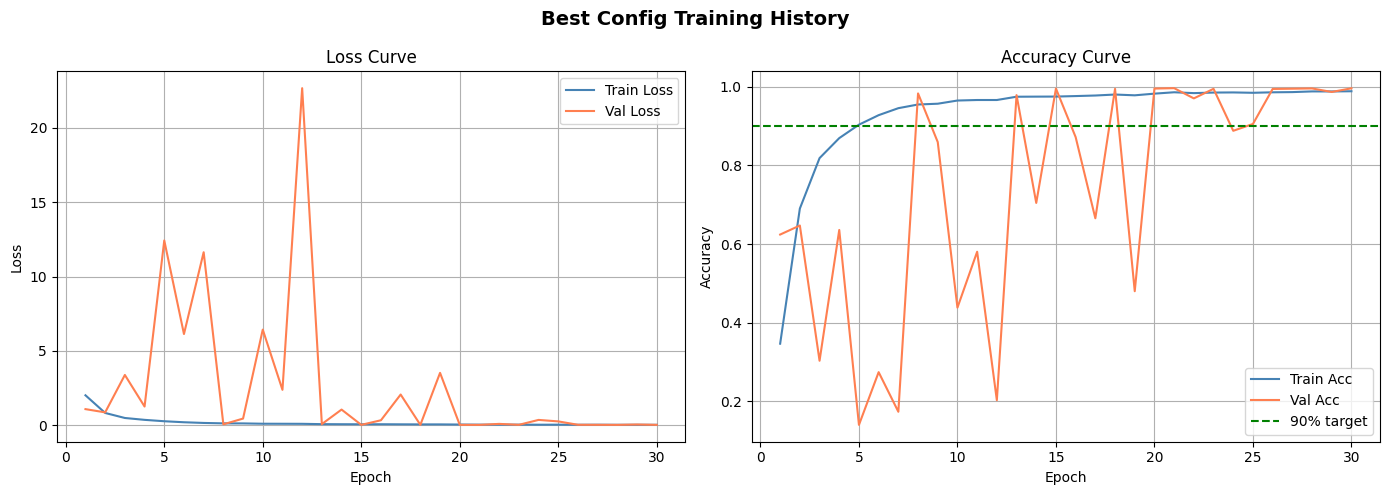

Saved: Best_Config_Training_History.png


In [ ]:
# ============================================================
# Cell 7: Plot training / validation loss and accuracy
# ============================================================
def plot_history(history, title="Training History"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
    axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="coral")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(True)

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train Acc", color="steelblue")
    axes[1].plot(epochs, history["val_acc"],   label="Val Acc",   color="coral")
    axes[1].axhline(0.90, linestyle="--", color="green", label="90% target")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy Curve"); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    fname = title.replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Saved: {fname}")

plot_history(best_history, title="Best Config Training History")

/tmp/ipykernel_1647/1345276717.py:26: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/1345276717.py:26: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/1345276717.py:26: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/1345276717.py:26: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/1345276717.py:26: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/1345276717.py:26: UserWarning: Glyph 20116 (\N{CJK UNIFIED IDEOGRAPH-4E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1647/1345276717.py:26: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}

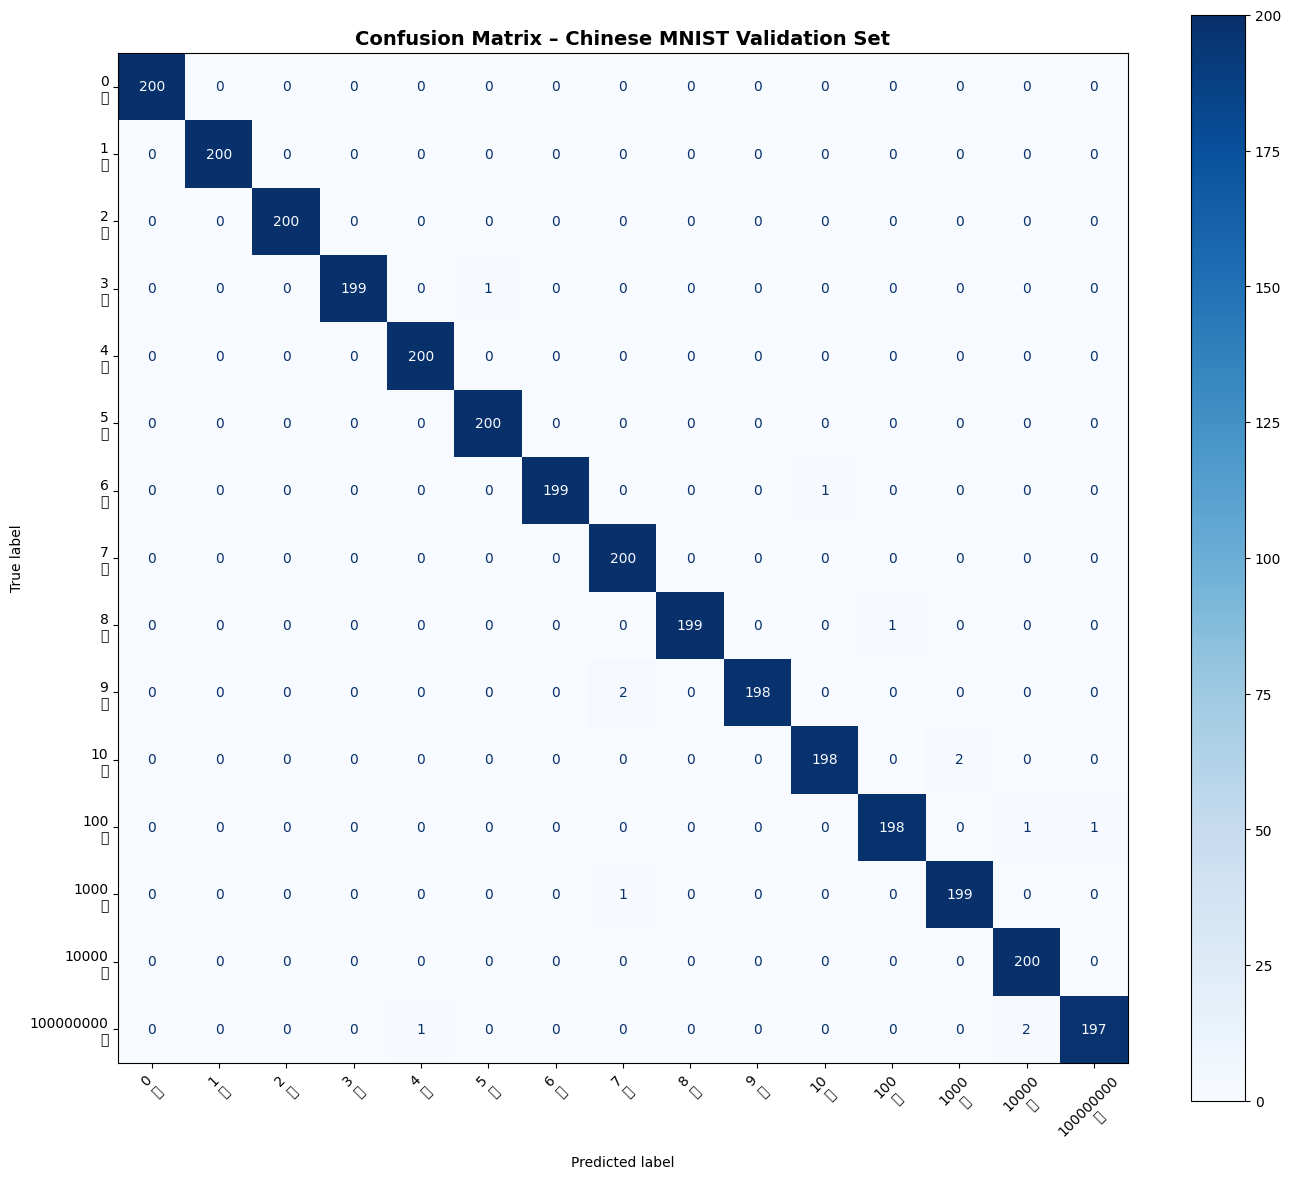

Saved: confusion_matrix.png

Most confused pair: True=九(9)  Predicted=七(7)  Count=2


In [ ]:
# ============================================================
# Cell 8: Confusion Matrix (sklearn)
# ============================================================
best_model.eval()

all_preds, all_labels = [], []

with torch.no_grad():                  # no gradient needed for evaluation
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = best_model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

# Class tick labels: integer label + Chinese character
class_labels = [f"{CODE_TO_VALUE[c+1]}\n{CODE_TO_CHAR[c+1]}" for c in range(15)]

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title("Confusion Matrix – Chinese MNIST Validation Set",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

# Identify most confused pairs
np.fill_diagonal(cm, 0)
max_idx = np.unravel_index(cm.argmax(), cm.shape)
print(f"\nMost confused pair: "
      f"True={CODE_TO_CHAR[max_idx[0]+1]}({max_idx[0]})  "
      f"Predicted={CODE_TO_CHAR[max_idx[1]+1]}({max_idx[1]})  "
      f"Count={cm[max_idx]}")